In [21]:
from autoreduce import *
import numpy as np

Classic SIR model is too simple, so I decided to go with the SEIRVD model https://www.tandfonline.com/doi/epdf/10.4161/viru.24041?needAccess=true

$
S=\text{Susceptible},\quad
E=\text{Exposed},\quad
I=\text{Infected},\quad
R=\text{Recovered},\quad
V=\text{Vaccinated},\quad
D=\text{Dead}
$

$
\begin{aligned}
x &=
\begin{bmatrix}
S \\
E \\
I \\
R \\
V \\
D
\end{bmatrix}
\end{aligned}
$

$
\begin{aligned}
\Theta &=
\begin{bmatrix}
\beta \\
\sigma \\
\gamma \\
\nu \\
\mu \\
N
\end{bmatrix}
\end{aligned}
$

$
\begin{aligned}
\dot{S} &= -\frac{\beta S I}{N} - \nu S \\
\dot{E} &= \frac{\beta S I}{N} - \sigma E \\
\dot{I} &= \sigma E - \gamma I - \mu I \\
\dot{R} &= \gamma I \\
\dot{V} &= \nu S \\
\dot{D} &= \mu I
\end{aligned}
$

$
\begin{aligned}
y &= I
\end{aligned}
$

S = Susceptible, E - Exposed, I = Infected, R = Recovered; SEIR ODE system

$
\begin{aligned}
\dot{S} &= -\frac{\beta S I}{N} \\
\dot{E} &= \frac{\beta S I}{N} - \sigma E \\
\dot{I} &= \sigma E - \gamma I \\
\dot{R} &= \gamma I
\end{aligned}
$

In [22]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# SEIRVD population model
n = 6
nouts = 1

# States:
# x[0] = S, Susceptible
# x[1] = E, Exposed
# x[2] = I, Infected
# x[3] = R, Recovered
# x[4] = V, Vaccinated
# x[5] = D, Dead

# Parameters:
# P[0] = beta   infection/transmission rate
# P[1] = sigma  exposed -> infected rate
# P[2] = gamma  recovery rate
# P[3] = nu     vaccination rate
# P[4] = mu     mortality/death rate
# P[5] = N      total population

P = np.zeros(6)

P[0] = 0.35     # beta
P[1] = 0.20     # sigma
P[2] = 0.10     # gamma
P[3] = 0.01     # nu
P[4] = 0.005    # mu
P[5] = 1000     # N

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100)

x_init = np.zeros(n)
x_init[0] = 990   # S
x_init[1] = 9     # E
x_init[2] = 1     # I
x_init[3] = 0     # R
x_init[4] = 0     # V
x_init[5] = 0     # D

error_tol = 100
nstates_tol = 2

x, f, P = load_ODE_model(n, len(params_values))
params = P

# SEIRVD ODEs
f[0] = -P[0] * x[0] * x[2] / P[5] - P[3] * x[0]

f[1] = P[0] * x[0] * x[2] / P[5] - P[1] * x[1]

f[2] = P[1] * x[1] - P[2] * x[2] - P[4] * x[2]

f[3] = P[2] * x[2]

f[4] = P[3] * x[0]

f[5] = P[4] * x[2]

# Output: infected population I
C = np.zeros((nouts, len(x)), dtype=int)
C[0][2] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)

Main thing that changed is that the varaible/out is x[2], which is the infected popuation & n = 6 as there are 3 more to account for

In [23]:
sys.x

[x0, x1, x2, x3, x4, x5]

In [24]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

Plotting libraries missing.


In [ ]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
#results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
results = sys_reduce.reduce_simple()

Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x2]!


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1229: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(
C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1215: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(


SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from P3*x0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x0, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x1, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x2, x3]!
SSM Progre

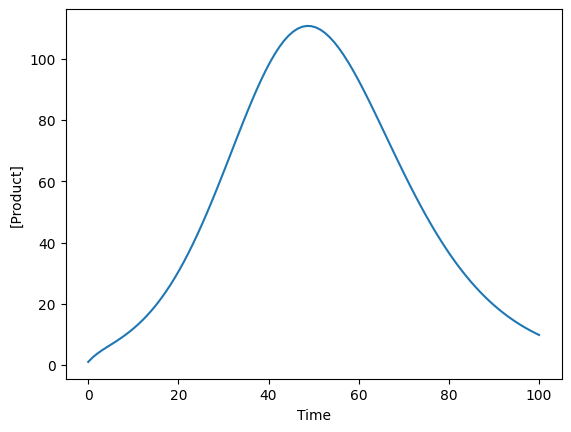

In [ ]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()

These two code blocks are copied and pasted from ProteinExpression code (where it autoassigns varaible names to the reduced models obtained from reduce.simple) & the graphing as well.

In [ ]:
reduced_models = list(results.keys())

#automatically names them
for i, model in enumerate(reduced_models):
    globals()[f"reduced_model_{i+1}"] = model

In [ ]:
from autoreduce.utils import get_ODE
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Solve original full model
sys_ode = get_ODE(sys, timepoints_ode)
orig_sol = sys_ode.solve_system().T

# Original output: y = Cx
orig_output = np.ravel(np.array(C) @ orig_sol)

reduced_results = []

for i, model in enumerate(reduced_models):
    try:
        red_ode = get_ODE(model, timepoints_ode)
        red_sol = red_ode.solve_system().T

        # reduced output
        red_C = np.array(model.C)
        red_output = np.ravel(red_C @ red_sol)

        # compare to original
        mae = np.mean(np.abs(orig_output - red_output))

        reduced_results.append({
            "name": f"Reduced model {i+1}: {model.x}",
            "model": model,
            "output": red_output,
            "mae": mae
        })

    except Exception as e:
        print(f"Reduced model {i+1} failed: {model.x}")
        print(e)

# Sort best to worst
reduced_results = sorted(reduced_results, key=lambda d: d["mae"])

# Color by error
mae_values = [r["mae"] for r in reduced_results]

norm = plt.Normalize(min(mae_values), max(mae_values))
cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse

fig = go.Figure()

# Original model as dotted black reference
fig.add_trace(
    go.Scatter(
        x=timepoints_ode,
        y=orig_output,
        mode="lines",
        name="Original full model",
        line=dict(color="black", dash="dot", width=4)
    )
)

# Add reduced models in sorted order
for r in reduced_results:
    rgba = cmap(norm(r["mae"]))
    color = (
        f"rgb({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)})"
    )

    fig.add_trace(
        go.Scatter(
            x=timepoints_ode,
            y=r["output"],
            mode="lines",
            name=f"{r['name']} | MAE={r['mae']:.3g}",
            line=dict(color=color, width=2)
        )
    )

fig.update_layout(
    title="Original vs Reduced Protein Expression Models",
    xaxis_title="Time",
    yaxis_title="Protein X",
    legend_title="Models sorted by closeness",
    template="plotly_white",
    width=1000,
    height=650
)

fig.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_34904\4062284274.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse


It seems the closest reduced models are #7,19,10,& 2 (using the criteria of < 40 MAE ), plotted it in LaTex belwo using skeleton code

In [ ]:
reduced_models = [
    ("7", reduced_model_7),
    ("19", reduced_model_19),
    ("10", reduced_model_2),
    ("2", reduced_model_2)
]

#automated printing out the title and function of the reduced model
from IPython.display import display, Math
from sympy import latex

#OG sys
display(Math(r"\text{Original System: } " + latex(sys.f)))

#redcced model function, states, & acutal function in LaTeX
for name, model in reduced_models:
    print(f"Reduced Model {name}")
    print("States:", model.x)
    display(Math(r"\text{Reduced Model " + name + r": } " + latex(model.f)))
    print("-" * 60)

<IPython.core.display.Math object>

Reduced Model 7
States: [x0, x1, x2]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 19
States: [x0, x1, x2, x5]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 10
States: [x0, x2]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 2
States: [x0, x2]


<IPython.core.display.Math object>

------------------------------------------------------------


Code for error copied over

In [ ]:
err = results[list(results.keys())[0]][0]
Se = results[list(results.keys())[0]][1]
weighted_se = 0
for p, Se_i in zip(params_values, Se):
    weighted_se += p*Se_i

In [ ]:
d_R = weighted_se/err
d_R

In [ ]:
w1 = 1
w2 = 1e-3
r = w1*err + w2*d_R
r